In [2]:
import numpy as np
from bisect import bisect_left
import pandas as pd
import os

In [3]:
from bisect import bisect_left

def time_to_seconds(t):
    h, m, s = map(int, t.split(":"))
    return h * 3600 + m * 60 + s


In [4]:
import pandas as pd

def process_day_file(txt_path, excel_path):
    times = []
    vis = []

    encodings = ['utf-8-sig', 'utf-16le', 'utf-16', 'latin-1']

    for enc in encodings:
        try:
            temp_times = []
            temp_vis = []
            with open(txt_path, "r", encoding=enc) as f:
                for line in f:
                    line = line.strip()
                    if line and (line[0].isdigit() or '\x00' in line):
                        parts = line.split()
                        if len(parts) >= 2:
                            ts = time_to_seconds(parts[0])
                            if ts is not None:
                                temp_times.append(ts)
                                temp_vis.append(float(parts[1]))

            if temp_times:
                times, vis = temp_times, temp_vis
                break
        except Exception:
            continue

    if not times:
        print(f"Skipping empty or invalid file: {txt_path}")
        return

    output = []
    for hour in range(24):
        target_00 = hour * 3600 
        idx = bisect_left(times, target_00)
        best = idx - 1 if idx > 0 and (idx == len(times) or abs(times[idx-1] - target_00) <= abs(times[idx] - target_00)) else idx
        if best < len(vis): output.append([f"{hour:02d}:00", vis[best]])

        target_30 = hour * 3600 + 29 * 60 + 29
        idx = bisect_left(times, target_30)
        best = idx - 1 if idx > 0 and (idx == len(times) or abs(times[idx-1] - target_30) <= abs(times[idx] - target_30)) else idx
        if best < len(vis): output.append([f"{hour:02d}:30", vis[best]])

    df_out = pd.DataFrame(output, columns=["Time", "Visibility"])
    df_out.to_excel(excel_path, index=False)

In [5]:

BASE_TXT_DIR = "RWY27_vis/RWY27"
BASE_XLSX_DIR = "RWY27_processed"

os.makedirs(BASE_XLSX_DIR, exist_ok=True)


In [6]:
count = 0

for root, _, filenames in os.walk(BASE_TXT_DIR):
    for filename in filenames:
        # your files start with date, e.g. 01.01.2020
        if filename[0].isdigit():
            txt_path = os.path.join(root, filename)

            # relative path from RWY27
            rel_path = os.path.relpath(root, BASE_TXT_DIR)

            # corresponding output directory
            out_dir = os.path.join(BASE_XLSX_DIR, rel_path)
            os.makedirs(out_dir, exist_ok=True)

            # output excel path
            excel_path = os.path.join(
                out_dir,
                filename + "_30min.xlsx"
            )

            process_day_file(txt_path, excel_path)
            count += 1

print(f"Processed {count} files")


Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\01.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\02.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\03.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\04.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\05.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\06.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\07.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\08.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\09.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\10.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\11.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\12.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\13.12.2021.txt
Skipping empty or invalid file: RWY27_vis/RWY27\2021\Dec\14.12.2

In [22]:
!find RWY27_processed -name "*.xlsx" | head -20


'head' is not recognized as an internal or external command,
operable program or batch file.


Overall Pearson correlation: 0.148
Total matched points: 4527


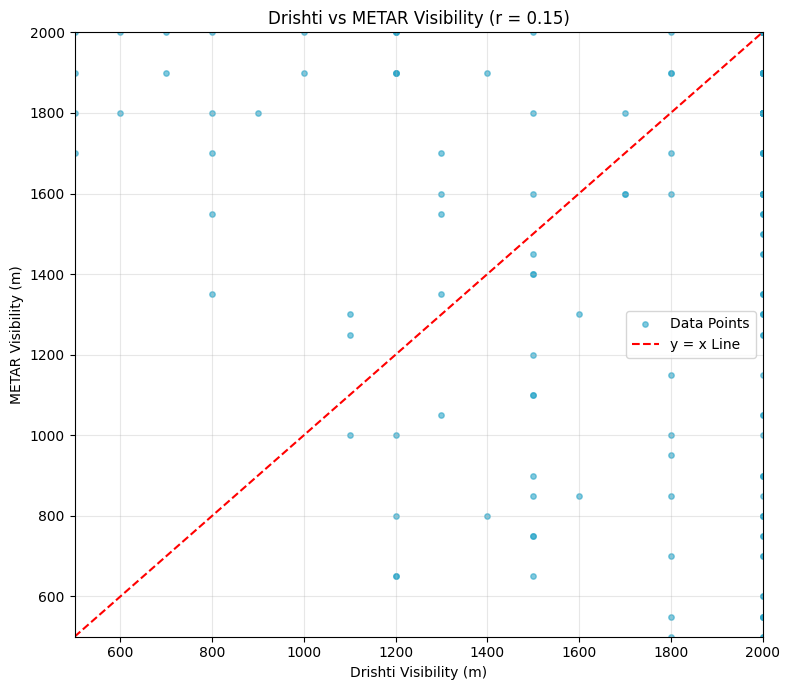

Saved visibility_correlation_plot.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr

# ================= CONFIG =================
DRISHTI_EXCEL_DIR = "RWY27_processed"
METAR_XLSX = "visibility_output_filtered.xlsx"
OUTPUT_PLOT_NAME = "visibility_correlation_plot.png"
CAP = 2000  # visibility cap (matches your reference plot)
# ==========================================


def load_metar_data(directory):
    all_dfs = []

    if not os.path.exists(directory):
        raise FileNotFoundError(f"METAR directory not found: {directory}")

    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith(".xlsx"):
                try:
                    # Example filename: 08.01.2023.txt_30min.xlsx
                    date_part = file.split(".txt")[0]  # 08.01.2023
                    path = os.path.join(root, file)

                    df = pd.read_excel(path)

                    # Ensure correct column names
                    df.columns = df.columns.str.strip()

                    # Build timestamp
                    df["timestamp"] = pd.to_datetime(
                        date_part + " " + df["Time"].astype(str),
                        dayfirst=True
                    )

                    # Ensure numeric visibility
                    df["METAR_Visibility"] = 2*(
                        df["Visibility"]
                        .astype(str)
                        .str.strip()
                        .astype(int)
                    )

                    all_dfs.append(df[["timestamp", "METAR_Visibility"]])

                except Exception as e:
                    print(f"Skipping {file}: {e}")

    if not all_dfs:
        raise RuntimeError("No METAR files were loaded.")

    return pd.concat(all_dfs, ignore_index=True)


def load_drishti_data(path):
    df = pd.read_excel(path)

    # Standardize column names
    df.columns = df.columns.str.strip().str.lower()

    # Parse timestamp
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Visibility is already numeric now
    df["Drishti_Visibility"] = pd.to_numeric(
        df["visibility"],
        errors="coerce"
    )

    # Drop bad rows
    df = df.dropna(subset=["timestamp", "Drishti_Visibility"])

    # Convert to int meters
    df["Drishti_Visibility"] = df["Drishti_Visibility"].astype(int)

    return df[["timestamp", "Drishti_Visibility"]]



def main():
    # ---------- Load ----------
    df_metar = load_metar_data(METAR_EXCEL_DIR)
    df_drishti = load_drishti_data(DRISHTI_XLSX)

    # ---------- Merge ----------
    df = pd.merge(
        df_drishti,
        df_metar,
        on="timestamp",
        how="inner"
    )

    if df.empty:
        raise RuntimeError("Merged dataframe is empty. Check timestamps.")

    # ---------- Single correlation for entire dataset ----------

    # Cap Drishti visibility
    df["Drishti_Plotting"] = df["Drishti_Visibility"].clip(upper=CAP)

    # Remove rows where either column is constant (optional but cleaner)
    if df["Drishti_Plotting"].nunique() == 1 or df["METAR_Visibility"].nunique() == 1:
        print("Correlation undefined: one variable is constant.")
        corr = float("nan")
    else:
        corr, _ = pearsonr(
            df["Drishti_Plotting"],
            df["METAR_Visibility"]
        )

    print(f"Overall Pearson correlation: {corr:.3f}")
    print(f"Total matched points: {len(df)}")

    # ---------- Plot ----------
    plt.figure(figsize=(8, 7))

    plt.scatter(
        df["Drishti_Plotting"],
        df["METAR_Visibility"],
        s=15,
        alpha=0.6,
        color="#2ba6c9",
        label="Data Points"
    )

    plt.plot([500, CAP], [500, CAP], "r--", label="y = x Line")

    plt.xlabel("Drishti Visibility (m)")
    plt.ylabel("METAR Visibility (m)")
    plt.title(f"Drishti vs METAR Visibility (r = {corr:.2f})")

    plt.xlim(500, CAP)
    plt.ylim(500, CAP)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT_NAME, dpi=300)
    plt.show()

    print(f"Saved {OUTPUT_PLOT_NAME}")

if __name__ == "__main__":
    main()

